# Laboratorio No. 4
- Sebastian Juárez 21471

Enlace al repositorio: https://github.com/SebasJuarez/CC3045/tree/Lab4

# Task 1

### 1. Explique con sus propias palabras, qué son los grafos computaciones y cuál es su importancia para el cálculo de gradientes en aplicaciones como backpropagation

Los grafos computacionales son estructuras matemáticas en forma de nodos y aristas que representan operaciones y datos en cálculos numéricos, especialmente en redes neuronales. Su importancia en el cálculo de gradientes radica en que permiten descomponer funciones complejas en pasos elementales, facilitando la derivación automática de cada operación. En aplicaciones como backpropagation, los grafos dirigidos ayudan a calcular eficientemente los gradientes mediante la regla de la cadena, optimizando el ajuste de los pesos en redes neuronales profundas.

### 2. Detalle cuales son los componentes y pasos que conforman una red neuronal. Con esto en mente, ¿cómo mejoraría el perceptrón que hizo en el laboratorio pasado?

Una red neuronal está compuesta por neuronas (unidades de procesamiento), pesos y sesgos (parámetros ajustables), capas (entrada, ocultas y salida) y funciones de activación (que introducen no linealidad). Su entrenamiento sigue pasos como la inicialización de parámetros, propagación hacia adelante, cálculo del error, retropropagación del gradiente y ajuste de pesos mediante optimización. 

Para mejorarlo, podriamos agregar ciertas capas para que mejore la convergencia, ademas de otros componentes y así tener un codigo optimo


### 3. Investigue y explique cómo se selecciona el valor K usando el método de la silueta para el algoritmo de K-Means. Explique las fórmulas (ecuaciones) que lo componen así como las asumpciones, si hay.

El método de la silueta mide la cohesión y separación de los clusters en K-Means, evaluando qué tan bien agrupados están los puntos en comparación con otros clusters. La fórmula de la silueta para un punto 𝑖 es:

![ecuacion](media/Ecuation.png)

### 4. Investigue sobre Principal Component Analysis (PCA) y responda respecto a algoritmos como K-Means ¿Cómo podría ayudarle a mejorar la calidad de sus clusters cuando se usa K-Means?

PCA ayuda a K-Means reduciendo la dimensionalidad de los datos, eliminando características redundantes y mejorando la separación de los clusters. Al transformar los datos a un espacio de menor dimensión con las componentes principales, se minimiza el ruido y se resaltan patrones que pueden facilitar la agrupación. Esto mejora la calidad de los clusters al evitar efectos de la maldición de la dimensionalidad y permitir que K-Means se enfoque en las características más relevantes para la clasificación.

# Task 2.1 - Analisis de los datos

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

plt.style.use('ggplot')

In [2]:
df = pd.read_csv('data/bank_transactions.csv')
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB
None


In [4]:
print(df.describe())

       CustAccountBalance  TransactionTime  TransactionAmount (INR)
count        1.046198e+06     1.048567e+06             1.048567e+06
mean         1.154035e+05     1.570875e+05             1.574335e+03
std          8.464854e+05     5.126185e+04             6.574743e+03
min          0.000000e+00     0.000000e+00             0.000000e+00
25%          4.721760e+03     1.240300e+05             1.610000e+02
50%          1.679218e+04     1.642260e+05             4.590300e+02
75%          5.765736e+04     2.000100e+05             1.200000e+03
max          1.150355e+08     2.359590e+05             1.560035e+06


In [5]:
selected_features = [
    'CustomerDOB', 
    'CustGender',
    'CustAccountBalance', 
    'TransactionAmount (INR)',
]

features = df[selected_features]

In [6]:
features.isnull().sum()

CustomerDOB                3397
CustGender                 1100
CustAccountBalance         2369
TransactionAmount (INR)       0
dtype: int64

In [7]:
features = features.dropna()

In [8]:
features.count()

CustomerDOB                1041765
CustGender                 1041765
CustAccountBalance         1041765
TransactionAmount (INR)    1041765
dtype: int64

### Encoding y transformación de valores

In [9]:
features['CustGender'] = features['CustGender'].map({'F': 1, 'M': 0}) 

features.rename(
    columns={
        'CustGender': 'Female?',
        'CustAccountBalance': 'Balance',
        'TransactionAmount (INR)': 'Amount',
    },
    inplace=True)

In [10]:
features = features.dropna()
features.count()

CustomerDOB    1041764
Female?        1041764
Balance        1041764
Amount         1041764
dtype: int64

In [11]:
features["CustomerDOB"] = pd.to_datetime(features["CustomerDOB"])

C:\Users\sebas\AppData\Local\Temp\ipykernel_10304\1050743629.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  features["CustomerDOB"] = pd.to_datetime(features["CustomerDOB"])


In [12]:
# Get the Customer age
features = features.drop(features[features['CustomerDOB'] == '1/1/1800'].index, axis=0)
features.loc[features.CustomerDOB.dt.year >= 2022, 'CustomerDOB'] = features.loc[features.CustomerDOB.dt.year >= 2022, 'CustomerDOB'] - pd.DateOffset(years=100)
features['CustomerAge'] = ((pd.to_datetime('today') - features['CustomerDOB']).dt.days / 365.25).round(0)

In [13]:
features.head()

,CustomerDOB,Female?,Balance,Amount,CustomerAge
0,1994-10-01,1.0,17819.05,25.0,30.0
1,1957-04-04,0.0,2270.69,27999.0,68.0
2,1996-11-26,1.0,17874.44,459.0,28.0
3,1973-09-14,1.0,866503.21,2060.0,51.0
4,1988-03-24,1.0,6714.43,1762.5,37.0


In [14]:
# Drop NaN values
features = features.dropna()

# Drop the CustomerDOB column
features = features.drop('CustomerDOB', axis=1)

In [15]:
features.head()

,Female?,Balance,Amount,CustomerAge
0,1.0,17819.05,25.0,30.0
1,0.0,2270.69,27999.0,68.0
2,1.0,17874.44,459.0,28.0
3,1.0,866503.21,2060.0,51.0
4,1.0,6714.43,1762.5,37.0


In [16]:
features.describe()

,Female?,Balance,Amount,CustomerAge
count,985473.000000,9.854730e+05,9.854730e+05,985473.00000
mean,0.276922,1.060590e+05,1.452449e+03,39.66863
std,0.447478,8.178443e+05,6.139422e+03,8.76247
min,0.000000,0.000000e+00,0.000000e+00,4.00000
25%,0.000000,4.581130e+03,1.510000e+02,34.00000
50%,0.000000,1.600759e+04,4.310000e+02,37.00000
75%,1.000000,5.375908e+04,1.125000e+03,43.00000
max,1.000000,1.150355e+08,1.560035e+06,102.00000


### Balanceo de clases

Vemos que la clase del genero esta desbalaceada por lo que se aplicara un balanceo y asi evitar problemas con la presicion 

In [17]:
features['Female?'].value_counts()

Female?
0.0    712574
1.0    272899
Name: count, dtype: int64

In [18]:
male = features[features['Female?'] == 0]
female = features[features['Female?'] == 1]
male = male.sample(n=len(female), random_state=7)
features = pd.concat([male, female])

In [19]:
features['Female?'].value_counts()

Female?
0.0    272899
1.0    272899
Name: count, dtype: int64

### Scaling

Vemos que hay valores muy distintos en ciertas clases por lo que si es necesario hacer un escalamiento

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [21]:
scaled_features = features.copy()

to_scale = ['Amount', 'CustomerAge', 'Balance']

scaled_features[to_scale] = scaler.fit_transform(scaled_features[to_scale])

scaled_features.head()

,Female?,Balance,Amount,CustomerAge
974270,0.0,-0.107183,-0.238270,0.167718
622443,0.0,-0.113533,-0.179216,0.507198
4768,0.0,-0.086650,-0.135219,-0.624402
37123,0.0,-0.116716,0.118060,0.507198
185587,0.0,-0.127482,-0.127022,0.280878


### Seleccion de las caracteristicas
En este caso, tomare en consideracion estas variables ya que son las que mejor se adaptan al problema que quiero investigar:

- 'Female?': para identificar el género del cliente (1 para mujer, 0 para hombre)
- 'Amount': para identificar el monto de la transacción realizada por el cliente
- 'CustomerAge': para identificar la edad del cliente
- 'Balance': para identificar el valor de la cuenta del cliente

# Task 2.1.1 K-Means

### Clusters

In [22]:
from sklearn.cluster import KMeans

In [23]:
# List to save the inertia for each number of clusters
inertia_values = []

# Range of cluster numbers to check
cluster_range = range(2, 11)

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=7)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

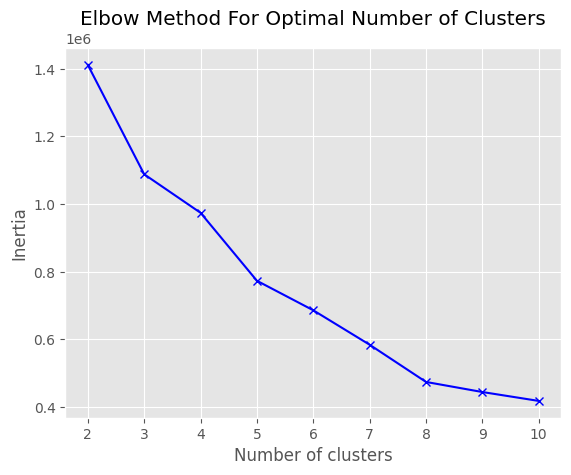

In [24]:
# Plotting the inertia values
plt.plot(cluster_range, inertia_values, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.show()

El número ideal de clusters es de 5.

## Modelo sin Librerías

In [25]:
def get_euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


class KMeansScratch:
    # Reference: https://www.youtube.com/watch?v=6UF5Ysk_2gk
    def __init__(self, K=5, max_iterations=100):
        self.K = K
        self.max_iterations = max_iterations

        # Each list contains the samples indices for the respective cluster
        self.clusters = [[] for _ in range(self.K)]

        # the centers (mean feature vector) for each cluster
        self.centroids = []

    def predict(self, X: pd.DataFrame):
        self.X = X
        self.n_samples, self.n_features = X.shape

        # Get random samples to be the initial centroids
        random_samples_ids = np.random.choice(self.n_samples, self.K, replace=False)
        self.centroids = [self.X.iloc[id] for id in random_samples_ids]

        # Optimize clusters
        for _ in range(self.max_iterations):
            # Assign samples to the closest centroids to create clusters
            self.clusters = self._create_clusters(self.centroids)

            # Calculate new centroids from the clusters
            old_centroids = self.centroids
            self.centroids = self._get_centroids(self.clusters)

            # Check if clusters have changed
            if self._has_converged(old_centroids, self.centroids):
                break

        # Classify samples as the index of their clusters
        return self._get_cluster_labels(self.clusters)

    def _create_clusters(self, centroids: list):
        clusters = [[] for _ in range(self.K)]

        for id, sample in enumerate(self.X.values):
            # Get the closest centroid for the sample
            centroid_id = self._closest_centroid(sample, centroids)
            clusters[centroid_id].append(id)

        return clusters

    def _closest_centroid(self, sample, centroids):
        distances = [get_euclidean_distance(sample, point) for point in centroids]
        closest_id = np.argmin(distances)

        return closest_id

    def _get_centroids(self, clusters: list):
        centroids = np.zeros((self.K, self.n_features))
        for cluster_id, cluster in enumerate(clusters):
            cluster_mean = np.mean(self.X.iloc[cluster], axis=0)
            centroids[cluster_id] = cluster_mean
        return centroids

    def _has_converged(self, old_centroids: list, centroids: list):
        distances = [get_euclidean_distance(old_centroids[i], centroids[i]) for i in range(self.K)]
        return sum(distances) == 0

    def _get_cluster_labels(self, clusters: list):
        labels = np.empty(self.n_samples)

        for cluster_id, cluster in enumerate(clusters):
            for sample_id in cluster:
                labels[sample_id] = cluster_id

        return labels


In [ ]:
kmeans_scratch = KMeansScratch()

predicted_clusters = kmeans_scratch.predict(scaled_features)

### Visualización de los Clusters generados

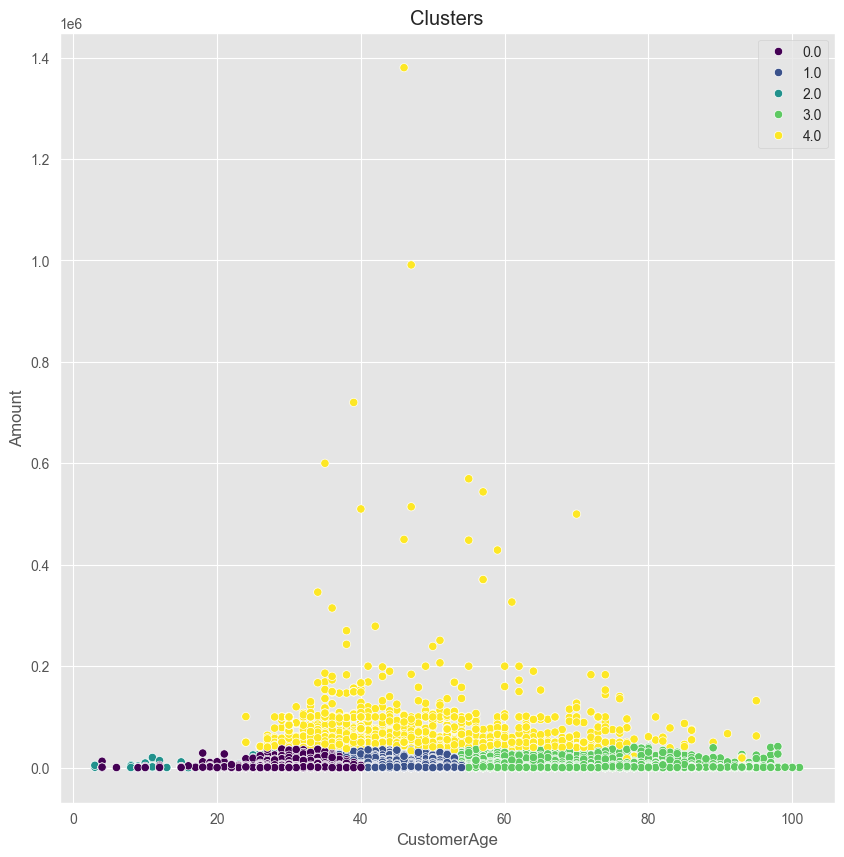

In [ ]:
# Plot the clusters
plt.figure(figsize=(10, 10))
sns.scatterplot(x='CustomerAge', y='Amount', data=features, hue=predicted_clusters, palette='viridis')
plt.title('Clusters')
plt.show()

### Evaluación del modelo

In [ ]:
# Silhouette score
from sklearn.metrics import silhouette_score

silhouette_score(scaled_features, predicted_clusters)

0.4202303630195806

El modelo tiene un silhouette score de 0.42, lo que significa que los clusters no están del todo bien definidos por la forma en que están distribuidos los datos. Aun así, nos da una idea de cómo podrían agruparse los clientes. Esta métrica ayuda a ver qué tan bien está cada punto en su grupo, con valores entre -1 y 1, donde 1 es lo ideal.

## Modelo con librerías

In [28]:
kmeans = KMeans(n_clusters=5, random_state=7)
pred_y = kmeans.fit_predict(scaled_features)

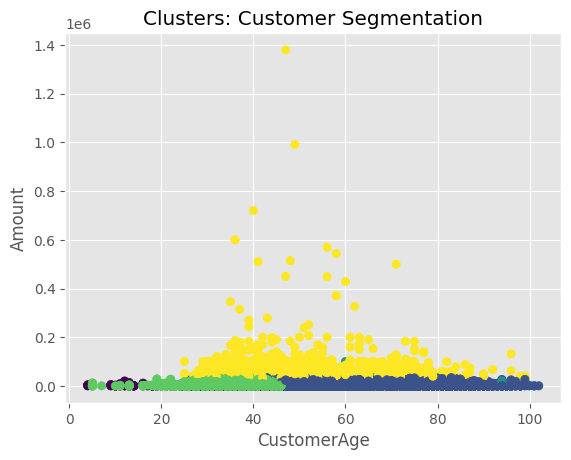

In [29]:
plt.scatter(x='CustomerAge', y='Amount', data=features, c=pred_y)
plt.xlabel('CustomerAge')
plt.ylabel('Amount')
plt.title('Clusters: Customer Segmentation')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(scaled_features, pred_y)
print('Silhouette Score: ', score)

Esta implementación da un silhouette score de 0.53, lo cual es un resultado decente dentro del rango de -1 a 1. Un valor cercano a 1 significa que los puntos están bien agrupados y separados de otros clusters. Como el puntaje es un poco mayor a 0.5, se puede considerar bastante bueno dado cómo están distribuidos los datos.

### Comparación de resultados
La mejor implementación fue con librerías, ya que logró un agrupamiento más preciso. Esto se debe a que las herramientas de aprendizaje automático en Python ofrecen mayor optimización y mejor manejo de los datos.

# Task 2.2 Mixture Models

## Modelo sin librerías

### ¿Podría PCA ayudarle a mejorar sus clusters? ¿Por qué?
Sí, PCA puede mejorar los clusters al reducir la dimensionalidad, lo que ayuda a separar mejor los puntos. Además, facilita la visualización al mejorar la dispersión de los datos.

In [ ]:
class GaussianMixtureModel:
    def __init__(self, n_components, max_iter=100, tol=1e-4):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol

    def initialize_parameters(self, X):
        n_samples, _ = X.shape
        # Randomly initialize means and covariances
        self.means = X[np.random.choice(n_samples, self.n_components, replace=False)]
        self.covariances = [np.cov(X.T) for _ in range(self.n_components)]
        # Initialize mixing coefficients uniformly
        self.weights = np.ones(self.n_components) / self.n_components

    def e_step(self, X):
        # Compute responsibilities (posterior probabilities)
        responsibilities = np.zeros((len(X), self.n_components))
        for k in range(self.n_components):
            responsibilities[:, k] = self.weights[k] * multivariate_normal.pdf(X, self.means[k], self.covariances[k])
        responsibilities /= np.sum(responsibilities, axis=1, keepdims=True)
        return responsibilities

    def m_step(self, X, responsibilities):
        # Update parameters
        N_k = np.sum(responsibilities, axis=0)
        self.weights = N_k / len(X)
        self.means = np.dot(responsibilities.T, X) / N_k[:, None]
        for k in range(self.n_components):
            diff = X - self.means[k]
            self.covariances[k] = np.dot(responsibilities[:, k] * diff.T, diff) / N_k[k]

    def fit(self, X):
        self.initialize_parameters(X)
        prev_likelihood = None
        for _ in range(self.max_iter):
            responsibilities = self.e_step(X)
            self.m_step(X, responsibilities)
            likelihood = np.sum(np.log(np.sum(responsibilities, axis=1)))
            if prev_likelihood is not None and np.abs(likelihood - prev_likelihood) < self.tol:
                break
            prev_likelihood = likelihood

    def predict(self, X):
        responsibilities = self.e_step(X)
        return np.argmax(responsibilities, axis=1)

In [ ]:
gmm = GaussianMixtureModel(n_components=4)

In [ ]:
samples = scaled_features.sample(1000)

gmm.fit(samples.values)

y_gmm = gmm.predict(samples.values)

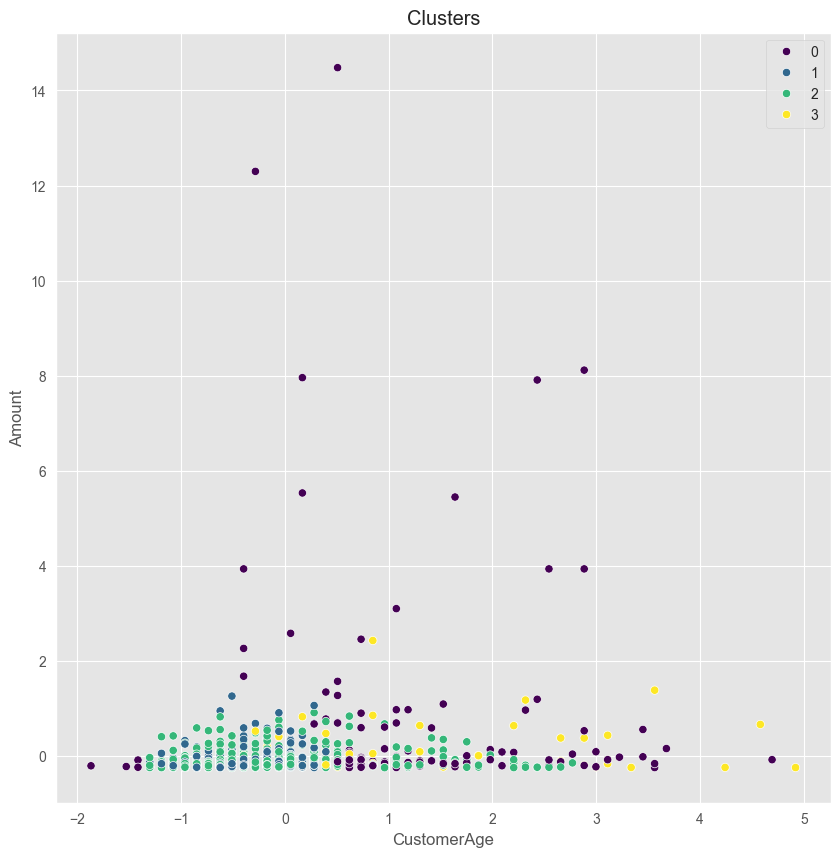

In [ ]:
# Plot the clusters
plt.figure(figsize=(10, 10))
sns.scatterplot(x='CustomerAge', y='Amount', data=samples, hue=y_gmm, palette='viridis')
plt.title('Clusters')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(samples, y_gmm)
print('Silhouette Score: ', score)

Silhouette Score:  0.3243355093030275


El modelo de Mixture Models sin librerías obtuvo un silhouette score de 0.324, lo que muestra que los clusters no están muy bien separados. Esto significa que varios puntos están cerca de los límites entre grupos y podrían estar en el cluster equivocado. La puntuación baja puede deberse a que el modelo no está tan optimizado o a que los datos son más complicados de agrupar.

## Modelo con librerías

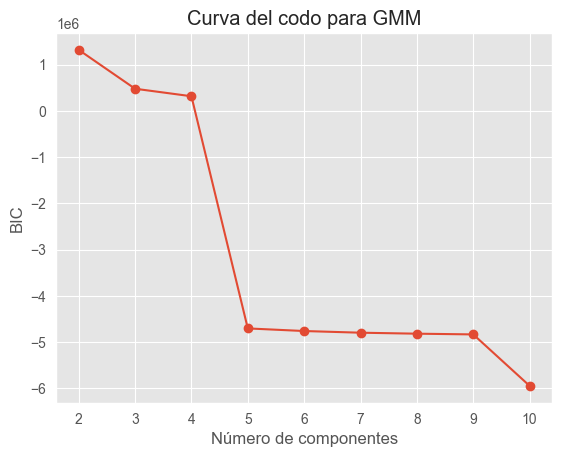

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

bic = []
n_components_range = range(2, 11)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=7)
    gmm.fit(scaled_features)
    bic.append(gmm.bic(scaled_features))

# Graficar la curva del codo (BIC)
plt.plot(n_components_range, bic, marker='o')
plt.title('Curva del codo para GMM')
plt.xlabel('Número de componentes')
plt.ylabel('BIC')
plt.xticks(n_components_range)
plt.show()

In [ ]:
gmm = GaussianMixture(n_components=5, random_state=7)
gmm.fit(scaled_features)
y_gmm = gmm.predict(scaled_features)

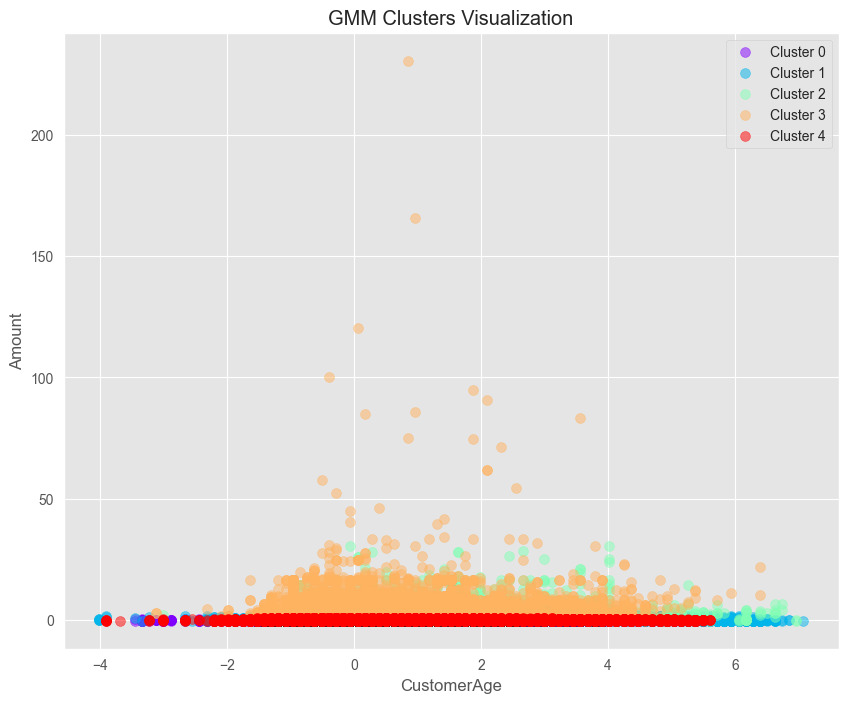

In [ ]:
def plot_clusters(X, labels, title='Clusters'):
    x_feature = 'CustomerAge'
    y_feature = 'Amount'

    plt.figure(figsize=(10, 8))
    
    unique_labels = np.unique(labels)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
    
    for label, color in zip(unique_labels, colors):
        cluster_data = X[labels == label]
        plt.scatter(cluster_data[x_feature], cluster_data[y_feature], s=50, color=color, alpha=0.5, label=f'Cluster {label}')
    
    plt.title(title)
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.legend()
    plt.show()
plot_clusters(scaled_features, y_gmm, 'GMM Clusters Visualization')

In [ ]:
score = silhouette_score(scaled_features, y_gmm)
print('Silhouette Score: ', score)

Silhouette Score:  0.3070699335254238


Esta implementación con librerías da un silhouette score de 0.31, lo que sugiere que algunas muestras están cerca de la frontera entre clusters. Esto podría significar que algunos puntos fueron asignados al grupo equivocado. El resultado es promedio y podría mejorar con un mejor preprocesamiento de datos.

### Comparación de resultados


Tanto el modelo sin librerías como el que usó librerías tuvieron resultados pobres. Esto podría deberse a la gran cantidad de features, ya que Mixture Models funciona mejor con un solo tipo de dato que se pueda clasificar según su valor.

## Comparación de modelos 'K-Means' y 'Mixture Models'

### ¿Cuál es mejor? ¿Por qué?
K-Means es mejor porque permite mayor flexibilidad al ajustar parámetros y obtuvo mejores métricas, con valores más cercanos a 1. Esto indica que el modelo logra una mejor separación de los clusters en comparación con Mixture Models.

### Considerando sus resultados, ¿cuándo cree que es mejor usar Mixture Models y K-Means?
El silhouette score de K-Means es más alto que el de GMM, lo que sugiere que separa mejor los clusters. Esto indica que los datos se ajustan mejor a K-Means, probablemente porque los clusters son esféricos y tienen varianzas similares. En cambio, Mixture Models sería más útil si los datos presentan distribuciones más complejas o superpuestas.